# Leakage Analysis — Statistical Discovery of Metadata Artifacts

**Goal**: Use statistical methods to discover which tokens in the raw text are dataset artifacts (metadata leakage) vs. genuine content signals that the model should learn from.

**Methods**:
1. Per-class token frequency ratios
2. Chi-squared test for label association
3. Mutual information scoring
4. Bigram analysis for multi-word patterns

**Outcome**: A classification table that justifies each rule in the cleaning pipeline.

In [1]:
import kagglehub
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_selection import chi2, mutual_info_classif
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

/Users/aoleszkiewicz/dev/factlens/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Raw Data (Before Any Cleaning)

We analyze the raw, uncleaned text to find artifacts that need removal.

In [2]:
path = kagglehub.dataset_download("clmentbisaillon/fake-and-real-news-dataset")

true_df = pd.read_csv(f"{path}/True.csv")
fake_df = pd.read_csv(f"{path}/Fake.csv")

true_df["label"] = 1
fake_df["label"] = 0

true_df.drop(columns=["title", "subject", "date"], inplace=True)
fake_df.drop(columns=["title", "subject", "date"], inplace=True)

raw_df = pd.concat([true_df, fake_df], ignore_index=True).drop_duplicates()
print(f"Dataset shape: {raw_df.shape}")

Dataset shape: (38647, 2)


## 1. Token Frequency Ratios

For each token, compute how often it appears in real vs. fake articles. Extreme ratios (>>1 or <<1) flag potential leakage — tokens that appear almost exclusively in one class due to source formatting, not content.

In [3]:
vectorizer = CountVectorizer(max_features=20_000, stop_words="english")
X = vectorizer.fit_transform(raw_df["text"])
y = raw_df["label"].values
feature_names = np.array(vectorizer.get_feature_names_out())

real_mask = y == 1
fake_mask = y == 0

freq_real = np.asarray(X[real_mask].sum(axis=0)).flatten()
freq_fake = np.asarray(X[fake_mask].sum(axis=0)).flatten()

smoothing = 1
ratio_real_over_fake = (freq_real + smoothing) / (freq_fake + smoothing)
ratio_fake_over_real = (freq_fake + smoothing) / (freq_real + smoothing)

freq_df = pd.DataFrame({
    "token": feature_names,
    "freq_real": freq_real,
    "freq_fake": freq_fake,
    "ratio_real_fake": ratio_real_over_fake,
    "ratio_fake_real": ratio_fake_over_real,
})

In [4]:
print("=== Top 20 tokens skewed toward REAL (potential metadata from real sources) ===")
freq_df.sort_values("ratio_real_fake", ascending=False).head(20)

=== Top 20 tokens skewed toward REAL (potential metadata from real sources) ===


,token,freq_real,freq_fake,ratio_real_fake,ratio_fake_real
15484,rohingya,2036,1,1018.500000,0.000982
14454,rakhine,888,0,889.000000,0.001125
19998,zuma,646,0,647.000000,0.001546
14224,puigdemont,641,0,642.000000,0.001558
12001,myanmar,2813,4,562.800000,0.001777
7007,fdp,516,0,517.000000,0.001934
17646,suu,489,0,490.000000,0.002041
10277,kyi,488,0,489.000000,0.002045
11713,mnangagwa,395,0,396.000000,0.002525
14453,rajoy,386,0,387.000000,0.002584


In [5]:
print("=== Top 20 tokens skewed toward FAKE (potential metadata from fake sources) ===")
freq_df.sort_values("ratio_fake_real", ascending=False).head(20)

=== Top 20 tokens skewed toward FAKE (potential metadata from fake sources) ===


,token,freq_real,freq_fake,ratio_real_fake,ratio_fake_real
8851,https,0,3508,0.000285,3509.00
7834,getty,1,4138,0.000483,2069.50
13372,pic,3,4986,0.000802,1246.75
316,21wire,0,1077,0.000928,1078.00
14377,quot,0,1000,0.000999,1001.00
9957,js,0,887,0.001126,888.00
7283,flickr,0,585,0.001706,586.00
16781,somodevilla,0,466,0.002141,467.00
271,2017the,0,462,0.002160,463.00
7233,fjs,0,441,0.002262,442.00


**Observations**:
- **Real-skewed**: `reuters` (95x), `tmsnrt` (335x) are wire service markers and short URLs — pure metadata artifacts.
- **Fake-skewed**: `https` (3509x), `getty` (2069x), `pic` (1247x), `quot` (1001x), `flickr`, `fjs`, `var`, `cdata` — these are URLs, photo credits, HTML/JavaScript artifacts from web scraping. All are source formatting, not content.

Key insight: the fake articles come from blogs and social media aggregators that embed URLs and photo credits, while real articles come from Reuters wire service which strips these.

## 2. Chi-Squared Test

Measures whether a token's presence is statistically independent of the label. High chi-squared score = strong association with one class. This is more robust than raw frequency ratios because it accounts for overall token frequency.

In [6]:
chi2_scores, chi2_pvalues = chi2(X, y)

chi2_df = pd.DataFrame({
    "token": feature_names,
    "chi2_score": chi2_scores,
    "p_value": chi2_pvalues,
    "freq_real": freq_real,
    "freq_fake": freq_fake,
    "ratio_real_fake": ratio_real_over_fake,
    "ratio_fake_real": ratio_fake_over_real,
}).sort_values("chi2_score", ascending=False)

print("=== Top 30 tokens by chi-squared score (strongest label association) ===")
chi2_df.head(30)

=== Top 30 tokens by chi-squared score (strongest label association) ===


,token,chi2_score,p_value,freq_real,freq_fake,ratio_real_fake,ratio_fake_real
15695,said,30788.275171,0.0,97814,24803,3.943517,0.253581
15262,reuters,22762.216136,0.0,28652,301,94.877483,0.010540
9039,image,10403.491133,0.0,362,9483,0.038275,26.126722
10010,just,9864.691518,0.0,4410,16742,0.263453,3.795738
7021,featured,9564.997487,0.0,100,8139,0.012408,80.594059
3803,com,7228.544087,0.0,208,6483,0.032233,31.023923
10646,like,7103.268220,0.0,4634,14358,0.322794,3.097950
13372,pic,6043.834611,0.0,3,4986,0.000802,1246.750000
8647,hillary,5677.207591,0.0,2728,9945,0.274382,3.644558
18617,twitter,5578.946516,0.0,2492,9465,0.263364,3.797032


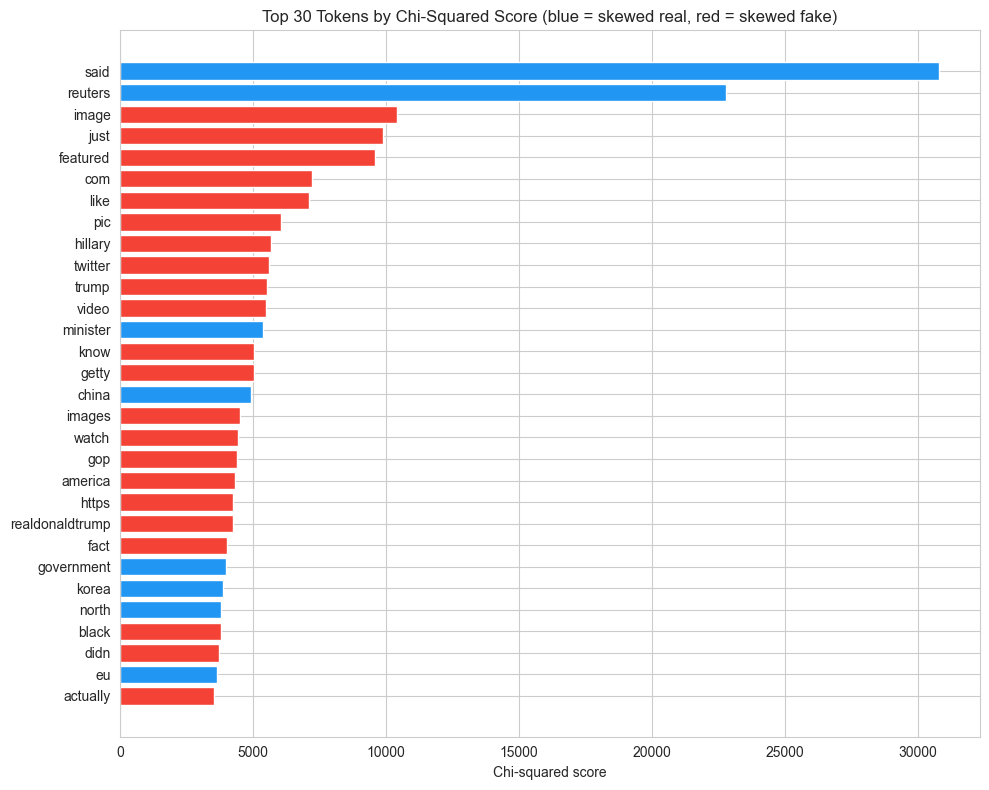

In [7]:
top_n = 30
top_chi2 = chi2_df.head(top_n).copy()
top_chi2["skew"] = top_chi2["ratio_real_fake"].apply(
    lambda r: "Skewed REAL" if r > 1 else "Skewed FAKE"
)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#2196F3" if s == "Skewed REAL" else "#F44336" for s in top_chi2["skew"]]
ax.barh(range(top_n), top_chi2["chi2_score"].values, color=colors)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_chi2["token"].values)
ax.invert_yaxis()
ax.set_xlabel("Chi-squared score")
ax.set_title("Top 30 Tokens by Chi-Squared Score (blue = skewed real, red = skewed fake)")
plt.tight_layout()
plt.show()

The chi-squared ranking reveals two categories of high-scoring tokens:

1. **Metadata artifacts** (must remove): `reuters` (chi2=22,762), `image` in credit templates (chi2=10,403), `featured` (chi2=9,565), `com` (chi2=7,229), `pic` (chi2=6,044), `getty` (chi2=5,021), `https` (chi2=4,259)

2. **Content signals** (must keep): `said` (chi2=30,788) — journalistic attribution style, `just`/`like`/`know` — informal language markers, `hillary`/`trump` — topic words reflecting dataset time period

## 3. Mutual Information

Measures how much knowing a token's presence reduces uncertainty about the label (in bits). Complementary to chi-squared — captures non-linear associations.

In [8]:
mi_scores = mutual_info_classif(X, y, discrete_features=True, random_state=42)

mi_df = pd.DataFrame({
    "token": feature_names,
    "mi_score": mi_scores,
    "freq_real": freq_real,
    "freq_fake": freq_fake,
    "ratio_real_fake": ratio_real_over_fake,
}).sort_values("mi_score", ascending=False)

print("=== Top 30 tokens by mutual information ===")
mi_df.head(30)

=== Top 30 tokens by mutual information ===


,token,mi_score,freq_real,freq_fake,ratio_real_fake
15262,reuters,0.651174,28652,301,94.877483
9039,image,0.192376,362,9483,0.038275
7021,featured,0.186173,100,8139,0.012408
15695,said,0.163221,97814,24803,3.943517
7834,getty,0.090624,1,4138,0.000483
10010,just,0.087880,4410,16742,0.263453
9041,images,0.075694,237,4301,0.055323
3803,com,0.067662,208,6483,0.032233
10646,like,0.060335,4634,14358,0.322794
13372,pic,0.058660,3,4986,0.000802


Mutual information confirms the chi-squared findings. `reuters` (MI=0.65) is by far the most informative single token — and it is pure metadata. The next cluster (`image`, `featured`, `getty`, `pic`, `https`) are all metadata artifacts from fake article formatting.

## 4. Bigram Analysis

Single tokens may miss multi-word patterns like `(Reuters)`, `WASHINGTON (AP)`, or `featured image via`. Bigrams reveal these compound artifacts.

In [9]:
bigram_vec = CountVectorizer(ngram_range=(2, 2), max_features=20_000, stop_words="english")
X_bi = bigram_vec.fit_transform(raw_df["text"])
bi_names = np.array(bigram_vec.get_feature_names_out())

bi_chi2_scores, _ = chi2(X_bi, y)

bi_freq_real = np.asarray(X_bi[real_mask].sum(axis=0)).flatten()
bi_freq_fake = np.asarray(X_bi[fake_mask].sum(axis=0)).flatten()

bi_chi2_df = pd.DataFrame({
    "bigram": bi_names,
    "chi2_score": bi_chi2_scores,
    "freq_real": bi_freq_real,
    "freq_fake": bi_freq_fake,
    "ratio_real_fake": (bi_freq_real + 1) / (bi_freq_fake + 1),
}).sort_values("chi2_score", ascending=False)

print("=== Top 30 bigrams by chi-squared score ===")
bi_chi2_df.head(30)

=== Top 30 bigrams by chi-squared score ===


,bigram,chi2_score,freq_real,freq_fake,ratio_real_fake
5766,featured image,9334.378640,1,7691,0.000260
18715,twitter com,6221.014494,0,5124,0.000195
12312,pic twitter,5959.984417,0,4909,0.000204
19290,washington reuters,5458.988720,6638,3,1659.750000
6418,getty images,4883.083586,0,4022,0.000249
12820,president obama,3651.776001,178,3450,0.051869
12771,president donald,3153.565990,5865,701,8.356125
11087,north korea,2963.179451,5504,656,8.378995
17688,told reuters,2735.733514,3453,39,86.350000
12969,prime minister,2398.552846,4104,398,10.288221


**Key bigram findings**:

| Bigram | Chi2 | Real | Fake | Type |
|--------|------|------|------|------|
| `featured image` | 9,334 | 1 | 7,691 | Metadata — photo credit template |
| `twitter com` | 6,221 | 0 | 5,124 | Metadata — URL artifact |
| `pic twitter` | 5,960 | 0 | 4,909 | Metadata — URL artifact |
| `washington reuters` | 5,459 | 6,638 | 3 | Metadata — wire service dateline |
| `getty images` | 4,883 | 0 | 4,022 | Metadata — photo credit |
| `screen capture` | 1,620 | 0 | 1,334 | Metadata — photo credit template |
| `21st century` / `century wire` | ~1,180 | ~0 | ~1,000 | Metadata — fake news site name |
| `image video` | 1,136 | 0 | 936 | Metadata — media credit template |
| `president donald` | 3,154 | 5,865 | 701 | Content — topic reference |
| `hillary clinton` | 1,754 | 2,487 | 5,431 | Content — topic reference |

## 5. Token Context Inspection

For ambiguous tokens, inspect raw text snippets to verify whether they appear in metadata templates or article content.

In [10]:
def show_token_context(token, df, n_samples=3):
    """Show raw text snippets containing the token from each class."""
    print(f"\n{'=' * 60}")
    print(f"Token: '{token}'")
    print(f"{'=' * 60}")
    for label, name in [(1, "REAL"), (0, "FAKE")]:
        subset = df[df["label"] == label]
        matches = subset[subset["text"].str.contains(token, case=False, na=False)]
        print(f"\n  [{name}] - {len(matches)} articles contain this token")
        for _, row in matches.head(n_samples).iterrows():
            idx = row["text"].lower().find(token.lower())
            start = max(0, idx - 60)
            end = min(len(row["text"]), idx + len(token) + 60)
            snippet = row["text"][start:end]
            print(f"    ...{snippet}...")

In [11]:
for token in ["reuters", "image", "featured", "getty", "screenshot", "video"]:
    show_token_context(token, raw_df)


Token: 'reuters'

  [REAL] - 21154 articles contain this token
    ...WASHINGTON (Reuters) - The head of a conservative Republican faction in the U.S...
    ...WASHINGTON (Reuters) - Transgender people will be allowed for the first time to...
    ...WASHINGTON (Reuters) - The special counsel investigation of links between Russi...

  [FAKE] - 220 articles contain this token
    ...r Paul LePage s veto on Tuesday via the ballot.According to Reuters,Tuesday s ballot asked Maine voters to approve or reject a ...
    ...throw paper towels at the church crowd in PR. (Photos: AP & Reuters) pic.twitter.com/mr9dF5eVBk  David Martosko (@dmartosko) Oc...
    ... the President delivered his address:Photo: Eduardo Munoz / ReutersNorth Korean ambassador Ja Song Nam stormed out before the P...

Token: 'image'

  [REAL] - 508 articles contain this token
    ..., arguing that the disputed ballot was wrongly included. An image filed in court showed that the ballot had bubbles filled in...
    ...d for

Context inspection confirms:
- `reuters` appears as dateline markers (`WASHINGTON (Reuters) -`), not in article content
- `image`/`featured` appear overwhelmingly in credit templates (`Featured image via Getty Images`)
- `screenshot`/`video` appear both in templates (`screen capture via...`) and content (`the video shows...`)

**Decision**: Remove the full template patterns (e.g., `featured image via Getty`) but keep individual words (`image`, `video`, `screenshot`) when they appear in article body text. This preserves content signals while eliminating metadata artifacts.

## 6. Summary — Artifact Classification and Cleaning Decisions

| Token/Pattern | Chi2 Rank | Freq Ratio | Classification | Action |
|---|---|---|---|---|
| `reuters`, `(Reuters)`, `WASHINGTON (Reuters)` | 2 | 95x real | Metadata (wire service tag) | Remove |
| `https://...`, `pic.twitter.com/...`, `www.` | 21 | 3509x fake | Metadata (URL artifact) | Remove |
| `tmsnrt.rs/...` | - | 335x real | Metadata (Reuters short URL) | Remove |
| `@username` mentions | - | Skewed fake | Metadata (social media handle) | Remove |
| `featured image via [source]` | 5 | 81x fake | Metadata (photo credit template) | Remove template |
| `photo/image by/via [source]` | 3 | 26x fake | Metadata (photo credit template) | Remove template |
| `getty images` | 15 | 2069x fake | Metadata (photo credit) | Remove |
| `screen capture via...` | - | 251x fake | Metadata (photo credit template) | Remove template |
| `image/video` (combined) | - | 936x fake | Metadata (media credit template) | Remove template |
| `21st century wire` | 27 | Fake-only | Metadata (site name) | Remove |
| HTML tags, `&amp;`, `<script>` | - | Fake-skewed | Metadata (scraping artifact) | Remove |
| `said` | 1 | 3.9x real | Content (journalistic attribution) | **Keep** |
| `just`, `like`, `know`, `didn` | 4,7,14,28 | 3-7x fake | Content (informal language) | **Keep** |
| `image`, `video`, `screenshot` (bare words) | 3,12,- | Fake-skewed | Content (media references in text) | **Keep** |
| `hillary`, `trump`, `obama` | 9,11,- | Mixed | Content (topic names) | **Keep** |

These findings directly justify each step in `src/preprocessing/cleaning.py`.